# PSD analysis — MET004TESTBLUE, R01

Uses `eeg.psd` (M3) to:
1. Plot the 23 per-trial PSDs for channel Oz in a grid.
2. Extract power at 10 Hz (exact bin, and a 9–11 Hz range as an alternative) for every trial and plot it against trial number.
3. Show channel combination: default (Oz only) vs. averaging Oz/O1/O2.

In [ ]:
from pathlib import Path

from eeg.eeglab_io import BASELINE_EVENT_ID, load_eeglab_epochs
from eeg.psd import band_power, combine_channels, compute_psd
from eeg.viz import plot_band_power_vs_trial, plot_psd_grid

In [2]:
DATA_ROOT = Path("/mnt/c/Users/zevaz/OneDrive/Escritorio/Metamers/eegExp/compsRem")
PARTICIPANT = "MET004TESTBLUE"
RUN = "R01"

epochs = load_eeglab_epochs(DATA_ROOT / PARTICIPANT / f"{RUN}.mat")
data = epochs.get_data()
sfreq = epochs.info["sfreq"]
baseline_mask = epochs.events[:, 2] == BASELINE_EVENT_ID

freqs, psd = compute_psd(data, sfreq)
print(f"psd shape (channels, freqs, trials): {psd.shape}")

Not setting metadata


23 matching events found


No baseline correction applied


0 projection items activated


psd shape (channels, freqs, trials): (32, 513, 23)


## 1. Grid of the 23 per-trial PSDs — Oz

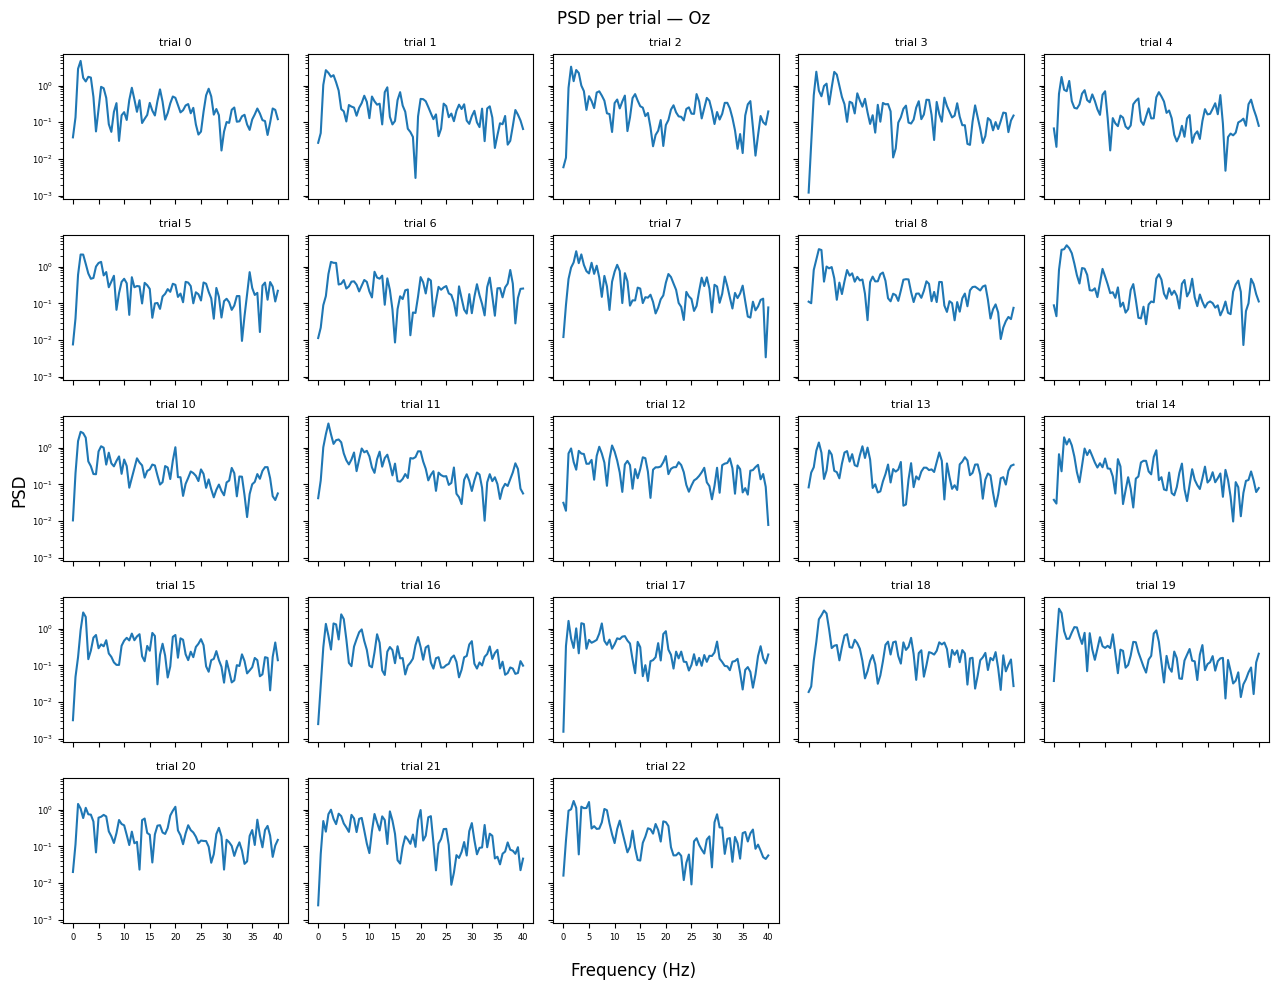

In [ ]:
fig = plot_psd_grid(psd, freqs, epochs.ch_names, channel="O1")

## 2. Power at 10 Hz vs. trial

`band_power` either snaps to the nearest frequency bin (a single float) or
averages a range (a `(low, high)` tuple).

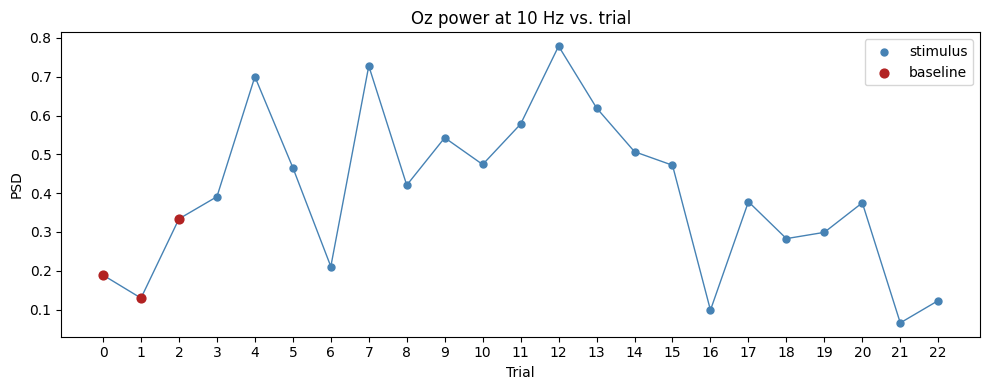

In [ ]:
spectrum_oz = combine_channels(psd, epochs.ch_names)  # default: ["Oz"]

power_10hz = band_power(freqs, spectrum_oz, 10.0)
fig = plot_band_power_vs_trial(power_10hz, "10 Hz", channel="O1", baseline_trial_idx=baseline_mask)

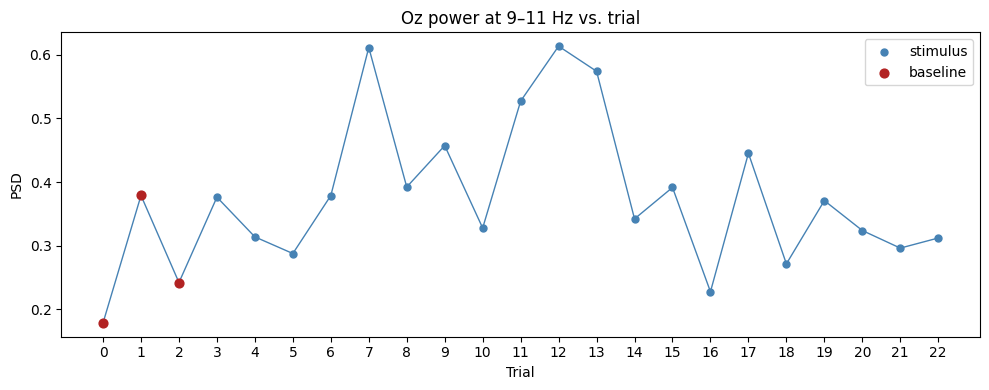

In [5]:
power_9_11hz = band_power(freqs, spectrum_oz, (9.0, 11.0))
fig = plot_band_power_vs_trial(power_9_11hz, "9\u201311 Hz", channel="Oz", baseline_trial_idx=baseline_mask)

## 3. Channel combination

`combine_channels(psd, channel_names)` defaults to `["Oz"]`. Passing a list
averages the PSD across those channels before extracting band power.

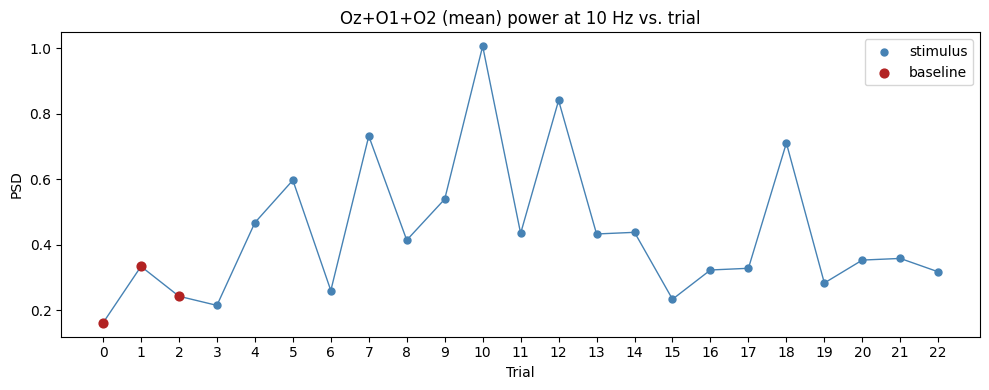

In [6]:
spectrum_occipital = combine_channels(psd, epochs.ch_names, channels=["Oz", "O1", "O2"])
power_10hz_occipital = band_power(freqs, spectrum_occipital, 10.0)

fig = plot_band_power_vs_trial(
    power_10hz_occipital, "10 Hz", channel="Oz+O1+O2 (mean)", baseline_trial_idx=baseline_mask
)